In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
df = pd.read_csv("Clarity_Export_Healy_Kurt_2026-04-03_025418.csv", skiprows=11)

In [3]:
bg = df[['11', 'iOS G7']]

In [4]:
print(bg.head())

                     11 iOS G7
12  2026-03-04T00:00:14     72
13  2026-03-04T00:05:13     73
14  2026-03-04T00:10:14     77
15  2026-03-04T00:20:13     61
16  2026-03-04T00:25:13     65


In [5]:
bg["11"] = pd.to_datetime(bg["11"])
march30 = bg[bg["11"].dt.date == pd.to_datetime("2026-03-30").date()]
march30['iOS G7'] = pd.to_numeric(march30['iOS G7'], errors='coerce')

/var/folders/fz/sp5lcgpj7n39l12p5kslyw980000gn/T/ipykernel_30892/3362465495.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bg["11"] = pd.to_datetime(bg["11"])
/var/folders/fz/sp5lcgpj7n39l12p5kslyw980000gn/T/ipykernel_30892/3362465495.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  march30['iOS G7'] = pd.to_numeric(march30['iOS G7'], errors='coerce')


In [6]:
print(march30)

                      11  iOS G7
7166 2026-03-30 00:02:36      59
7167 2026-03-30 00:07:36      60
7168 2026-03-30 00:12:36      64
7169 2026-03-30 00:17:36      59
7170 2026-03-30 00:22:37      57
...                  ...     ...
7448 2026-03-30 23:37:38     120
7449 2026-03-30 23:42:38     121
7450 2026-03-30 23:47:38     108
7451 2026-03-30 23:52:38     107
7452 2026-03-30 23:57:37     119

[287 rows x 2 columns]


In [7]:
print(march30['iOS G7'])

7166     59
7167     60
7168     64
7169     59
7170     57
       ... 
7448    120
7449    121
7450    108
7451    107
7452    119
Name: iOS G7, Length: 287, dtype: int64


In [8]:
print(march30['iOS G7'][7166])

59


In [9]:
print(march30.dtypes)

11        datetime64[ns]
iOS G7             int64
dtype: object


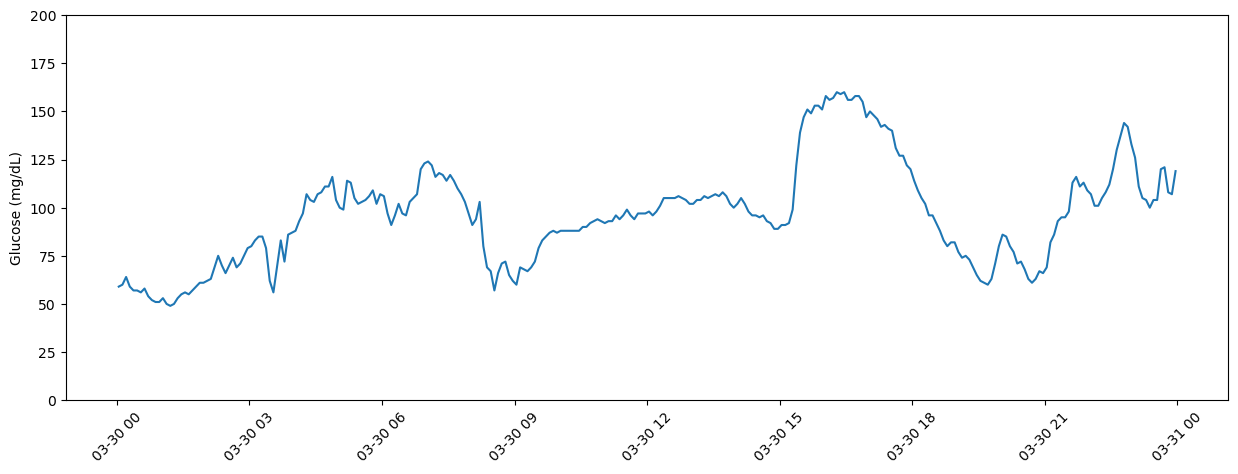

In [10]:
plt.figure(figsize=(15, 5))
plt.plot(march30['11'], march30['iOS G7'])
plt.xticks(rotation=45)
plt.ylabel("Glucose (mg/dL)")
plt.ylim(0, 200) 
plt.show()

In [11]:
date = "2026-03-30"

schedule = [
    ("00:00", "03:00", 0.550),
    ("03:00", "05:00", 1.6),
    ("05:00", "08:00", 1.7),
    ("08:00", "19:30", 0.95),
    ("19:30", "23:59", 0.650),
]

insulin_df = pd.DataFrame(schedule, columns=["start", "end", "rate"])

insulin_df["start"] = pd.to_datetime(date + " " + insulin_df["start"])
insulin_df["end"] = pd.to_datetime(date + " " + insulin_df["end"])

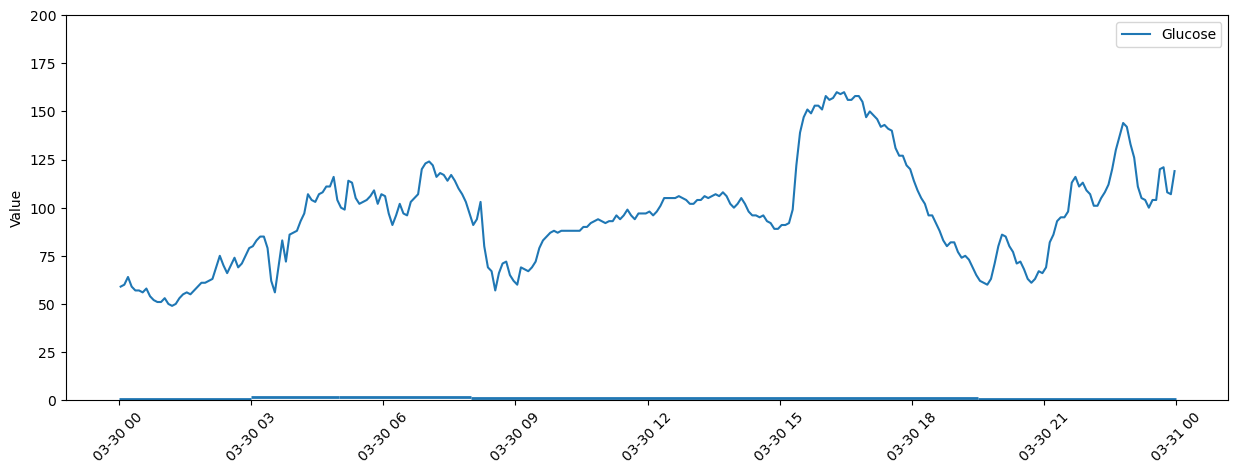

In [12]:
plt.figure(figsize=(15,5))

plt.plot(march30["11"], march30["iOS G7"], label="Glucose")

for _, row in insulin_df.iterrows():
    plt.hlines(
        y=row["rate"],
        xmin=row["start"],
        xmax=row["end"],
        linewidth=2
    )

plt.ylim(0, 200)
plt.xticks(rotation=45)
plt.ylabel("Value")
plt.legend()
plt.show()

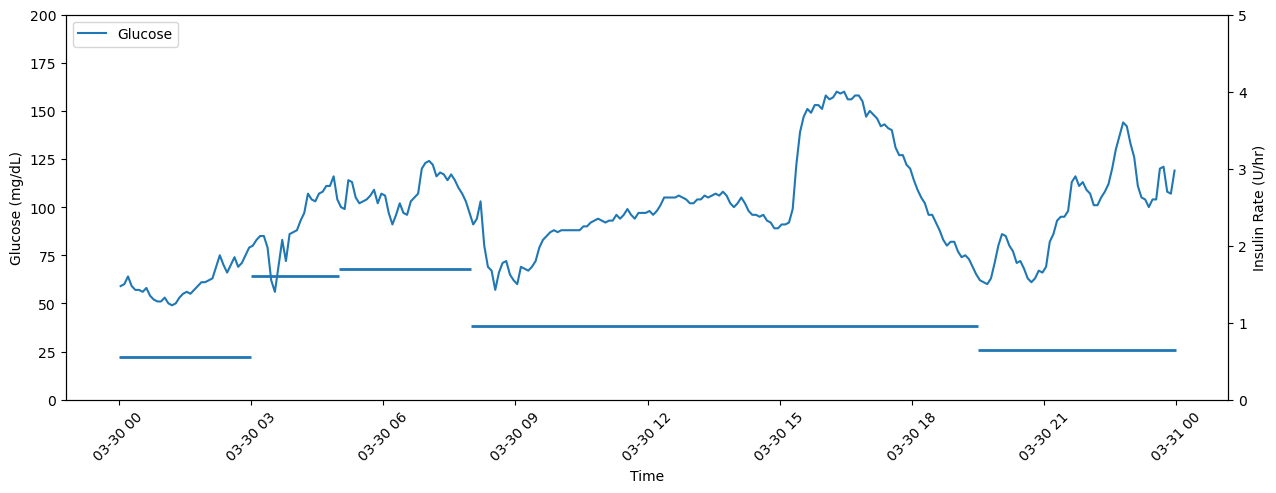

In [13]:
fig, ax1 = plt.subplots(figsize=(15,5))

# Plot glucose on left axis
ax1.plot(march30["11"], march30["iOS G7"], label="Glucose")
ax1.set_ylabel("Glucose (mg/dL)")
ax1.set_ylim(0, 200)

# Create second axis for insulin
ax2 = ax1.twinx()
ax2.set_ylim(0, 5)

# Plot basal insulin on right axis
for _, row in insulin_df.iterrows():
    ax2.hlines(
        y=row["rate"],
        xmin=row["start"],
        xmax=row["end"],
        linewidth=2
    )

ax2.set_ylabel("Insulin Rate (U/hr)")

# Labels / formatting
ax1.set_xlabel("Time")
ax1.tick_params(axis='x', rotation=45)

# Optional: combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc="upper left")

plt.show()

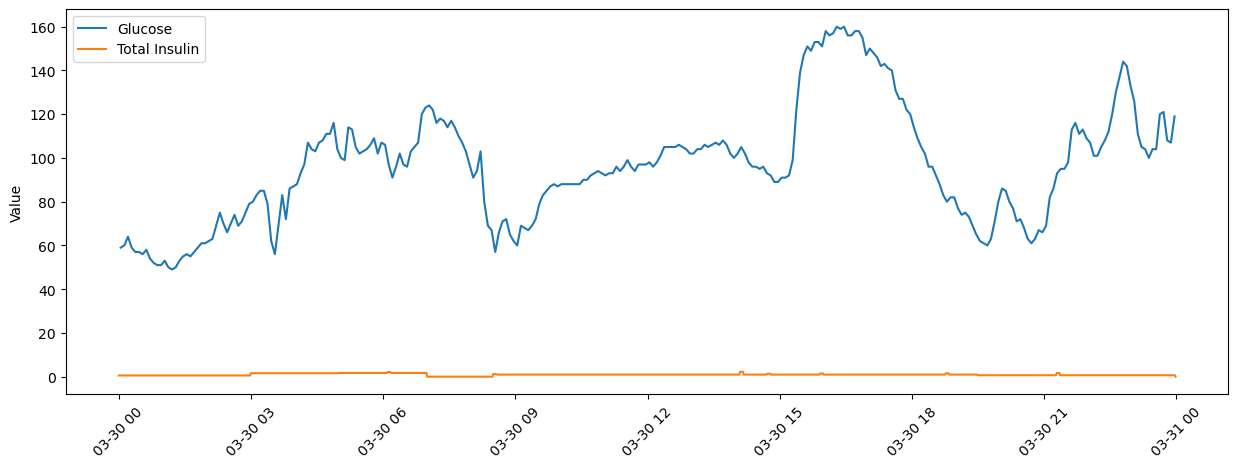

In [14]:

date = "2026-03-30"

schedule = [
    ("00:00", "03:00", 0.550),
    ("03:00", "05:00", 1.6),
    ("05:00", "07:00", 1.7),
    ("07:00", "08:30", 0.0),
    ("08:30", "19:30", 0.95),
    ("19:30", "23:59", 0.650),
]

boluses = [
    ("06:06", 2.1),
    ("08:30", 1.0),
    ("14:06", 6.4),
    ("14:43", 2.1),
    ("15:55", 2.5),
    ("18:46", 3.0),
    ("21:17", 5.1),
]

# -----------------------------
# Basal dataframe
# -----------------------------
insulin_df = pd.DataFrame(schedule, columns=["start", "end", "rate"])
insulin_df["start"] = pd.to_datetime(date + " " + insulin_df["start"])
insulin_df["end"] = pd.to_datetime(date + " " + insulin_df["end"])

# -----------------------------
# Bolus dataframe
# -----------------------------
bolus_df = pd.DataFrame(boluses, columns=["time", "dose"])
bolus_df["timestamp"] = pd.to_datetime(date + " " + bolus_df["time"])

# Expand each bolus into 5 one-minute entries
def expand_bolus(row):
    times = pd.date_range(start=row["timestamp"], periods=5, freq="1min")
    per_minute = row["dose"] / 5
    return pd.DataFrame({"timestamp": times, "bolus_rate": per_minute})

expanded_boluses = pd.concat(
    [expand_bolus(row) for _, row in bolus_df.iterrows()],
    ignore_index=True
)

# -----------------------------
# Time grid (1-minute resolution)
# -----------------------------
time_index = pd.date_range(
    start=f"{date} 00:00",
    end=f"{date} 23:59",
    freq="1min"
)

insulin_series = pd.DataFrame({"timestamp": time_index})

# -----------------------------
# Assign basal rate
# -----------------------------
def get_basal_rate(t):
    for _, row in insulin_df.iterrows():
        if row["start"] <= t < row["end"]:
            return row["rate"]
    return 0

insulin_series["basal"] = insulin_series["timestamp"].apply(get_basal_rate)

# -----------------------------
# Add bolus contributions
# -----------------------------
bolus_agg = expanded_boluses.groupby("timestamp")["bolus_rate"].sum().reset_index()

insulin_series = insulin_series.merge(bolus_agg, on="timestamp", how="left")
insulin_series["bolus_rate"] = insulin_series["bolus_rate"].fillna(0)

# Total insulin
insulin_series["total_insulin"] = insulin_series["basal"] + insulin_series["bolus_rate"]

# -----------------------------
# Plot (assuming march30 exists)
# -----------------------------
plt.figure(figsize=(15,5))

# Glucose
plt.plot(march30["11"], march30["iOS G7"], label="Glucose")

# Insulin
plt.plot(insulin_series["timestamp"], insulin_series["total_insulin"], label="Total Insulin")

plt.xticks(rotation=45)
plt.ylabel("Value")
plt.legend()
plt.show()

/var/folders/fz/sp5lcgpj7n39l12p5kslyw980000gn/T/ipykernel_30892/3188266683.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)


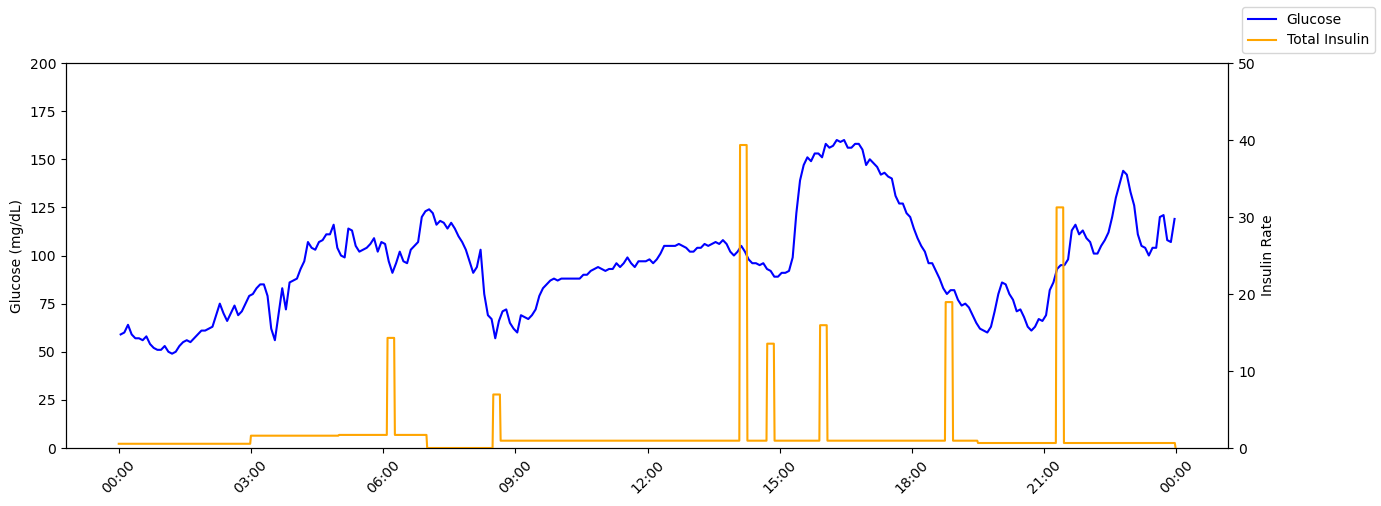

In [18]:

date = "2026-03-30"

schedule = [
    ("00:00", "03:00", 0.550),
    ("03:00", "05:00", 1.6),
    ("05:00", "07:00", 1.7),
    ("07:00", "08:30", 0.0),
    ("08:30", "19:30", 0.95),
    ("19:30", "23:59", 0.650),
]

boluses = [
    ("06:06", 2.1),
    ("08:30", 1.0),
    ("14:06", 6.4),
    ("14:43", 2.1),
    ("15:55", 2.5),
    ("18:46", 3.0),
    ("21:17", 5.1),
]

# -----------------------------
# Basal dataframe
# -----------------------------
insulin_df = pd.DataFrame(schedule, columns=["start", "end", "rate"])
insulin_df["start"] = pd.to_datetime(date + " " + insulin_df["start"])
insulin_df["end"] = pd.to_datetime(date + " " + insulin_df["end"])

# -----------------------------
# Bolus dataframe
# -----------------------------
bolus_df = pd.DataFrame(boluses, columns=["time", "dose"])
bolus_df["timestamp"] = pd.to_datetime(date + " " + bolus_df["time"])

def expand_bolus(row):
    times = pd.date_range(start=row["timestamp"], periods=10, freq="1min")
    per_minute = row["dose"] * 6
    return pd.DataFrame({"timestamp": times, "bolus_rate": per_minute})

expanded_boluses = pd.concat(
    [expand_bolus(row) for _, row in bolus_df.iterrows()],
    ignore_index=True
)

# -----------------------------
# Time grid
# -----------------------------
time_index = pd.date_range(
    start=f"{date} 00:00",
    end=f"{date} 23:59",
    freq="1min"
)

insulin_series = pd.DataFrame({"timestamp": time_index})

# -----------------------------
# Basal rate assignment
# -----------------------------
def get_basal_rate(t):
    for _, row in insulin_df.iterrows():
        if row["start"] <= t < row["end"]:
            return row["rate"]
    return 0

insulin_series["basal"] = insulin_series["timestamp"].apply(get_basal_rate)

# -----------------------------
# Add bolus contributions
# -----------------------------
bolus_agg = expanded_boluses.groupby("timestamp")["bolus_rate"].sum().reset_index()

insulin_series = insulin_series.merge(bolus_agg, on="timestamp", how="left")
insulin_series["bolus_rate"] = insulin_series["bolus_rate"].fillna(0)

# Total insulin
insulin_series["total_insulin"] = insulin_series["basal"] + insulin_series["bolus_rate"]

# -----------------------------
# Plot with dual y-axes
# -----------------------------
fig, ax1 = plt.subplots(figsize=(15, 5))

# Glucose (left axis)
ax1.plot(march30["11"], march30["iOS G7"], label="Glucose", color="blue")
ax1.set_ylabel("Glucose (mg/dL)")
ax1.set_ylim(0, 200)

# Format x-axis as time of day
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Insulin (right axis)
ax2 = ax1.twinx()
ax2.set_ylim(0, 50)
ax2.plot(insulin_series["timestamp"], insulin_series["total_insulin"], label="Total Insulin", color="orange")
ax2.set_ylabel("Insulin Rate")

# Formatting
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
fig.legend(loc="upper right")

plt.show()